In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
from urllib.parse import urlparse
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from difflib import SequenceMatcher
import joblib

# Constants

In [52]:
sus_extensions = [".exe", ".zip", ".rar", ".js", ".php"]
KNOWN_BRANDS = [
    'paypal', 'google', 'apple', 'microsoft', 'amazon',
    'facebook', 'instagram', 'netflix', 'ebay','icloud', 'linkedin',
    'dropbox', 'yahoo', 'outlook', 'chase', 'wellsfargo',
    'bankofamerica', 'instagram', 'whatsapp', 'twitter'
    ]
labels = {
        'phishing':   0,
        'benign':     1,
        'defacement': 2,
        'malware':    3
    }
labels_reversed = {v: k for k, v in labels.items()}
label_names = ["phishing", "benign", "defacement", "malware"]

# FeatureEngineering

In [11]:
#parsing URL
def safe_parse(url):
    url = str(url).strip()
    if not url.startswith("http"):
            url = "http://" + url
    try:
        parsed = urlparse(url)
        _ = parsed.hostname  # forces urlparse to validate crashes here if bad
        return parsed.netloc or '', parsed.hostname or '', parsed.path or '', parsed.query or '', parsed.scheme or ''
    except ValueError:
        raise

def typosquat_score(hostname):
    domain_name = hostname.split('.')[0] if '.' in hostname else hostname
        
    scores = []
    for brand in KNOWN_BRANDS:
        ratio = SequenceMatcher(None, domain_name.lower(), brand).ratio()
        scores.append(ratio)
        
    best_match = max(scores)
    if best_match > 0.8 and domain_name.lower() not in KNOWN_BRANDS:
        return best_match
    return 0.
        
#Extracting features
def extract_features(url):
    #Getting URL extension
    netloc, hostname, path, query, scheme = safe_parse(url)
    _, extension = os.path.splitext(path)

    brand_in_domain = 1 if any(
    brand in hostname.lower() for brand in KNOWN_BRANDS
    ) else 0

    official_domains = {b + '.com' for b in KNOWN_BRANDS}
    brand_impersonation = (
    1 if brand_in_domain and hostname.lower() not in official_domains
    else 0
    )

    #Engineering features
    features = {
        "url_length":len(url),
        "has_ip": 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0,
        "dot_count": url.count('.'),
        "at_count": url.count('@'),
        "hyphen_count": url.count('-'),
        "path_depth": len([p for p in path.split('/') if p]),
        "query_length": len(query),
        "digit_ratio": sum(c.isdigit() for c in netloc) / max(len(netloc),1),
        "domain_length": len(netloc),
        "subdomain_count": netloc.count('.') - 1,
        "file_extensions": 1 if extension in sus_extensions else 0,
        "brand_copying": brand_impersonation,
        "typosquat_score": typosquat_score(hostname)
    }

    return features

# FeatureDataframeBuilt

In [38]:
def feature_df(csv):
    print(f"Loading csv from {csv}")
    df = pd.read_csv(csv)

    feature_rows = []
    failed_indices = []

    print("Checking for unparseable URLs...")
    for i, url in enumerate(df['url']):
        try:
            row = extract_features(url)
            feature_rows.append(row)
        except Exception as e:
            failed_indices.append(i)

    if failed_indices:
        print(f"Dropped {len(failed_indices)} unparseable URLs out of {len(df)}")
        df = df.drop(index=failed_indices).reset_index(drop=True)

    feature_df = pd.DataFrame(feature_rows) 
    feature_df['label'] = df['type'].str.lower().str.strip().map(labels)

    missing_sum = feature_df['label'].isna().sum()
    if missing_sum > 0:
        print(f"Detected {missing_sum} missing rows!")
        print("Deleting detected empty rows...")
        feature_df = feature_df.dropna(subset=['label'])

    feature_df['label'] = feature_df['label'].astype(int)

    print("\nFeature extraction complete!")
    print(f"Features: {list(feature_df.columns[:-1])}\n")

    return feature_df

# SplittingData

In [26]:
def prepare_data(df):
    x = df.drop(columns='label')
    y = df['label']
    
    #Splitting data
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
    print(f"Training raws: {len(x_train)}")
    print(f"Testing raws: {len(x_test)}")
    
    #Scaling x_train data
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    return x_train_scaled, x_test_scaled, y_train, y_test, scaler, x.columns.tolist()

# ModelTraining

In [40]:
def model_definition():
    return [
        ("RandomForest", 
         RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1)
        ),
        ("XGBoost", 
         XGBClassifier(class_weight='balanced', n_estimators=100,learning_rate=0.1,max_depth=6,
                       random_state=42,n_jobs=-1,verbosity=0,use_label_encoder=False,eval_metric='mlogloss')
        ),
        ("LogisticrRegression",
         LogisticRegression(max_iter=1000,random_state=42, n_jobs=-1)   
        )
    ]

def plotting_cm(cm, title, cmap='Blues'):
    plt.figure(figsize=(7,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names
    )
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    plt.close()

def train_individual_models(csv):
    df = feature_df(csv)
    x_train, x_test, y_train, y_test, _, _ = prepare_data(df)
    results = []
    trained = {}
    
    for name,model in model_definition():
        print(f"Training: {name}")
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        accuracy = accuracy_score(y_test, y_pred)
    
        print(f"Accuracy:{accuracy*100:.2f}%")
        print(f"Classification Report for {name}:")
        print(classification_report(y_test, y_pred, target_names=label_names))

        plotting_cm(confusion_matrix(y_test, y_pred),
                   title=f"Confusion Matrix - {name}")
    
        results.append({"Model":name, "Accuracy":round(accuracy*100, 2)})
        trained[name] = model

    results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
    print("\nModel summary")
    print(results_df.to_string(index=False))
    best = results_df.iloc[0]
    print(f"\nBest individual model: {best['Model']} at {best['Accuracy']}%")

    return trained

# VotingClassifier

In [46]:
def voting_classifier(csv):
    df = feature_df(csv)
    x_train, x_test, y_train, y_test, scaler, _ = prepare_data(df)
    
    print("Training Voting Classifier...")
    voting_clf = VotingClassifier(
        estimators=[(n, m) for n, m in model_definition()],
        voting='soft'
    )
    
    voting_clf.fit(x_train, y_train)
    y_pred_vote = voting_clf.predict(x_test)
    voting_accuracy = accuracy_score(y_test, y_pred_vote)
    
    print(f"Voting Classifier Accuracy: {voting_accuracy * 100:.2f}%")
    print(f"\nClassification Report — Voting Classifier:")
    print(classification_report(y_test, y_pred_vote, target_names=label_names))
    
    plotting_cm(
        confusion_matrix(y_test, y_pred_vote),
        title    = 'Confusion Matrix - Voting Classifier',
        cmap     = 'Greens'
    )
    
    joblib.dump(voting_clf, 'voting_clf.pkl')
    joblib.dump(scaler, 'scaler.pkl')
    print("\nTrained Model Saved!")
    print("Scaler Saved!\n")


# PredictingURL

In [53]:
def predicting_URL(url):
    try:
        voting_clf = joblib.load('voting_clf.pkl')
        scaler = joblib.load('scaler.pkl')
    except FileNotFoundError:
        print("No saved models, Please select option 2 to train model first...")
        return

    try:
        features = extract_features(url)
    except Exception as e:
        print("Cannot parse url!: {e}")
        return

    feature_df = pd.DataFrame([features])
    features_scaled = scaler.transform(feature_df)

    prediction = voting_clf.predict(features_scaled)[0]
    probability = voting_clf.predict_proba(features_scaled)[0]

    print("Final Prediction")
    print(f"URL:{url}")
    print(f"PREDICTION:{labels_reversed[prediction].upper()}")
    print(f"PROBABILITY:{max(probability) * 100:.2f}%")

# Main

In [35]:
def main():
    print("Malicious URL Detection Model")

    while True:
        print("\nSelect an option:")
        print("1. Train and evaluate all 3 models seperately")
        print("2. Train and save voting classifier")
        print("3. Predict URL")
        print("4. Exit")

        try:
            choice = int(input("\nEnter option:"))
        except TypeError:
            print("Enter a valid int value")
            continue
            
        if choice == 1:
            print("Option 1 selected")
            csv = input("Enter your csv path:")
            print("\n")
            if not os.path.exists(csv):
                print(f"Path invalid, File does not exist at {csv}")
                continue
            train_individual_models(csv)

        elif choice == 2:
            print("Option 2 selected")
            csv = input("Enter your csv path:")
            print("\n")
            if not os.path.exists(csv):
                print(f"Path invalid, File does not exist at {csv}")
                continue
            voting_classifier(csv)

        elif choice == 3:
            print("Option 3 selected")
            url = input("Enter your url:").strip()
            print("\n")
            if not url:
                print("No URL entered!")
                continue
            predicting_URL(url)

        elif choice == 4:
            print("Thank you - Have a great day!")
            break

        else:
            print("Please enter a valid option through 1-4\n")

Malicious URL Detection Model

Select an option:
1. Train and evaluate all 3 models seperately
2. Train and save voting classifier
3. Predict URL
4. Exit



Enter option: 1


Option 1 selected


Enter your csv path: malicious_phish.csv




Loading csv from malicious_phish.csv
Checking for unparseable URLs...
Dropped 17 unparseable URLs out of 651191

Feature extraction complete!
Features: ['url_length', 'has_ip', 'dot_count', 'at_count', 'hyphen_count', 'path_depth', 'query_length', 'digit_ratio', 'domain_length', 'subdomain_count', 'file_extensions', 'brand_copying', 'typosquat_score']

Training raws: 520939
Testing raws: 130235
Training: RandomForest
Accuracy:88.44%
Classification Report for RandomForest:
              precision    recall  f1-score   support

    phishing       0.71      0.78      0.75     18819
      benign       0.94      0.91      0.92     85621
  defacement       0.82      0.86      0.84     19291
     malware       0.93      0.93      0.93      6504

    accuracy                           0.88    130235
   macro avg       0.85      0.87      0.86    130235
weighted avg       0.89      0.88      0.89    130235



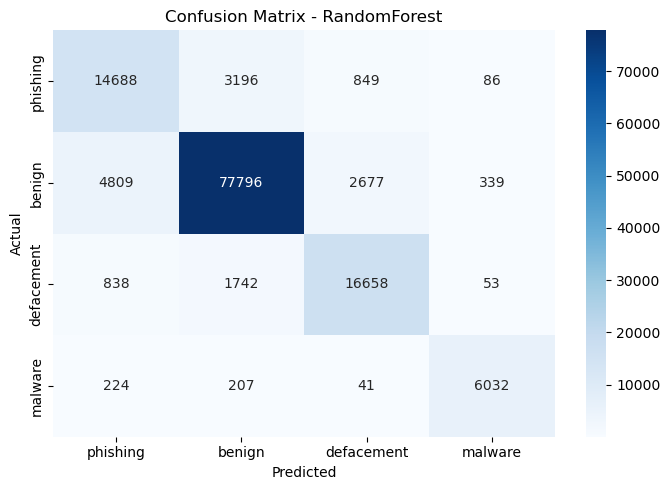

Training: XGBoost
Accuracy:83.48%
Classification Report for XGBoost:
              precision    recall  f1-score   support

    phishing       0.76      0.51      0.61     18819
      benign       0.84      0.95      0.89     85621
  defacement       0.81      0.67      0.73     19291
     malware       0.95      0.79      0.87      6504

    accuracy                           0.83    130235
   macro avg       0.84      0.73      0.77    130235
weighted avg       0.83      0.83      0.83    130235



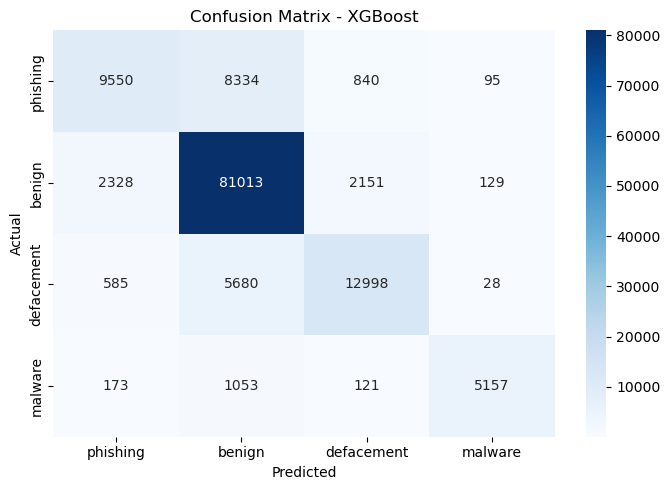

Training: LogisticrRegression
Accuracy:72.74%
Classification Report for LogisticrRegression:
              precision    recall  f1-score   support

    phishing       0.51      0.07      0.13     18819
      benign       0.73      0.96      0.83     85621
  defacement       0.67      0.43      0.52     19291
     malware       0.87      0.51      0.65      6504

    accuracy                           0.73    130235
   macro avg       0.69      0.49      0.53    130235
weighted avg       0.70      0.73      0.67    130235



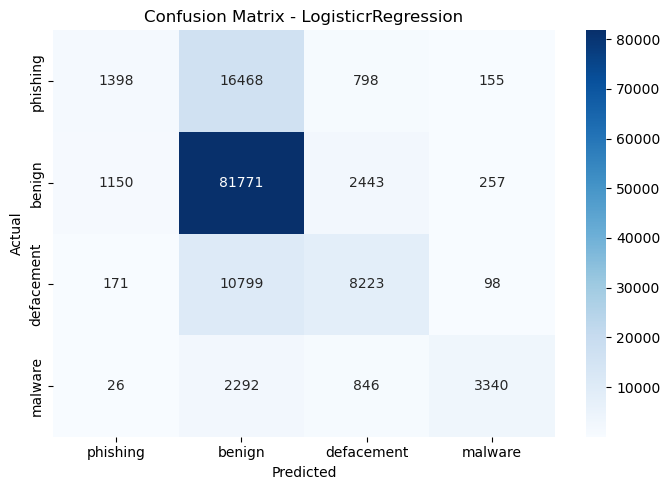


Model summary
              Model  Accuracy
       RandomForest     88.44
            XGBoost     83.48
LogisticrRegression     72.74

Best individual model: RandomForest at 88.44%

Select an option:
1. Train and evaluate all 3 models seperately
2. Train and save voting classifier
3. Predict URL
4. Exit


In [ ]:
if __name__ == '__main__':
    main()